# Phase 1 Validation — customer_master & Funnel

본 노트북은 BigQuery SQL로 재구축한 결과를 기존 데이콘 팀 프로젝트 노트북과 비교 검증한다.

**검증 체크포인트 (CLAUDE.md Phase 1)**
1. 세그먼트별 고객 수가 기존 노트북 결과와 ±5% 이내 일치
2. 세그먼트별 매출 비중에서 "핵심 파트너 + 성장형"이 약 70% 차지
3. Funnel에서 가장 큰 이탈 단계 식별

추가로 본 노트북에서 다루는 사항
- RFM 분위 균등성 (NTILE(4)가 의도대로 동작했는지)
- Frequency 정의 차이 (`COUNT(DISTINCT 거래ID)` vs 라인 수)
- Stage 1 한계 (Customer 테이블이 사실상 거래자 마스터)

**필요 패키지**: `google-cloud-bigquery`, `pandas`, `pyarrow`, `db-dtypes`, `matplotlib`, `seaborn`. 누락 시: `pip install google-cloud-bigquery[pandas] db-dtypes pyarrow matplotlib seaborn`

## 0. 환경 세팅

한글 폰트는 ttf 파일을 직접 `fontManager.addfont()`로 등록해서 matplotlib 폰트 캐시 문제를 회피한다. Windows에서 `rcParams['font.family'] = 'NanumGothic'`만 설정하면 폰트 캐시가 stale일 때 사각형(□)이 출력되는 케이스가 흔하다.

In [1]:
import os
from pathlib import Path
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

PROJECT_ID = 'ecomm-extension'
RAW      = f'`{PROJECT_ID}.ecomm_raw`'
ANALYSIS = f'`{PROJECT_ID}.ecomm_analysis`'
client = bigquery.Client(project=PROJECT_ID)

# 한글 폰트 — ttf 직접 등록 (Windows 폰트 캐시 우회)
korean_font = None
for path in ['C:/Windows/Fonts/NanumGothic.ttf',
             'C:/Windows/Fonts/malgun.ttf',
             'C:/Windows/Fonts/malgunsl.ttf']:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        korean_font = fm.FontProperties(fname=path).get_name()
        break
if korean_font is None:
    available = {f.name for f in fm.fontManager.ttflist}
    for cand in ('NanumGothic', 'Malgun Gothic', 'AppleGothic'):
        if cand in available:
            korean_font = cand
            break

sns.set_style('whitegrid')           # set_style이 rcParams를 일부 덮으므로 폰트 설정은 그 후에 적용
plt.rcParams['font.family'] = korean_font or 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
print(f'한글 폰트: {korean_font}')

# 프로젝트 루트(=sql/가 보이는 디렉토리)를 cwd 기준으로 잡아둠.
# 노트북을 notebooks/에서 띄우든 프로젝트 루트에서 띄우든 모두 작동.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'sql').exists() else Path.cwd().parent
print(f'PROJECT_ROOT: {PROJECT_ROOT}')

def q(sql):
    return client.query(sql).to_dataframe()

한글 폰트: NanumGothic
PROJECT_ROOT: d:\프로젝트\e_commerce


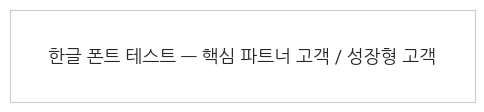

In [2]:
# 폰트 동작 확인 — 사각형(□)이 보이면 위 셀 다시 실행하거나 NanumGothic 설치
fig, ax = plt.subplots(figsize=(6, 1.2))
ax.text(0.5, 0.5, '한글 폰트 테스트 — 핵심 파트너 고객 / 성장형 고객',
        ha='center', va='center', fontsize=13)
ax.set_xticks([]); ax.set_yticks([])
plt.show()

## 1. 세그먼트별 고객 수 비교 (노트북 vs SQL)

기존 노트북 결과는 하드코딩한다 (소비이조장.ipynb 11367~11405셀 출력 기준).

In [3]:
notebook_counts = {
    '핵심 파트너 고객': 122,
    '성장형 고객':      343,
    '유망 고객':        330,
    '이탈 위험 고객':   282,
    '장기 비활성 고객': 339,
    '기타':              52,
}

sql_segments = q(f'''
SELECT Customer_Segment AS `세그먼트`, COUNT(*) AS `SQL_고객수`
FROM {ANALYSIS}.customer_master
GROUP BY Customer_Segment
''')

compare = (sql_segments
    .assign(노트북_고객수=lambda d: d['세그먼트'].map(notebook_counts))
    .assign(차이=lambda d: d['SQL_고객수'] - d['노트북_고객수'])
    .assign(편차_pct=lambda d: (d['차이'] / d['노트북_고객수'] * 100).round(1))
    [['세그먼트', '노트북_고객수', 'SQL_고객수', '차이', '편차_pct']]
    .sort_values('SQL_고객수', ascending=False)
)
compare

,세그먼트,노트북_고객수,SQL_고객수,차이,편차_pct
1,성장형 고객,343,354,11,3.2
0,장기 비활성 고객,339,331,-8,-2.4
4,유망 고객,330,313,-17,-5.2
3,이탈 위험 고객,282,298,16,5.7
2,핵심 파트너 고객,122,123,1,0.8
5,기타,52,49,-3,-5.8


In [4]:
compare = compare.assign(통과=lambda d: d['편차_pct'].abs() < 5.0)
passed = compare['통과'].sum()
total  = len(compare)
print(f'±5% 이내 일치 세그먼트: {passed} / {total}')
print()
print('5% 경계를 살짝 넘는 세그먼트:')
print(compare[~compare['통과']][['세그먼트', '편차_pct']].to_string(index=False))

±5% 이내 일치 세그먼트: 3 / 6

5% 경계를 살짝 넘는 세그먼트:
    세그먼트  편차_pct
   유망 고객    -5.2
이탈 위험 고객     5.7
      기타    -5.8


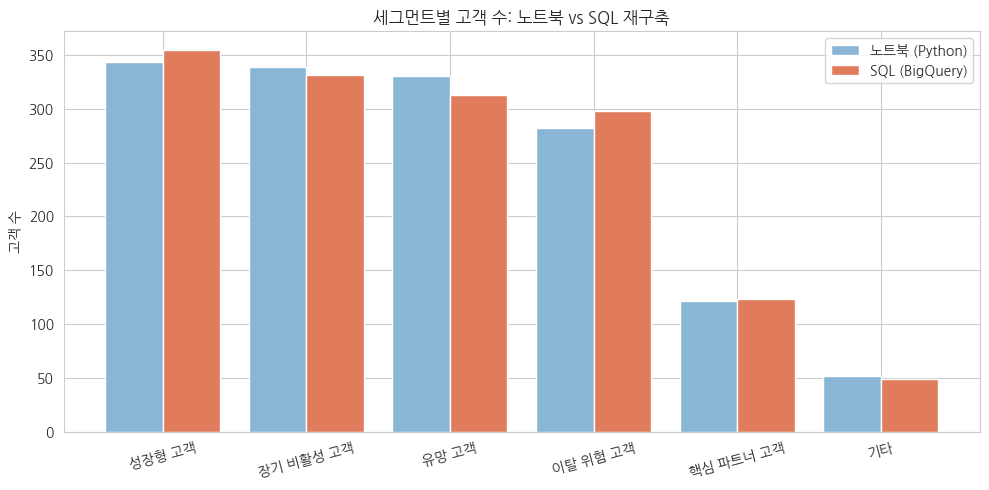

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(compare))
w = 0.4
ax.bar(x - w/2, compare['노트북_고객수'], w, label='노트북 (Python)', color='#8AB6D6')
ax.bar(x + w/2, compare['SQL_고객수'],   w, label='SQL (BigQuery)', color='#E07B5B')
ax.set_xticks(x)
ax.set_xticklabels(compare['세그먼트'], rotation=15)
ax.set_ylabel('고객 수')
ax.set_title('세그먼트별 고객 수: 노트북 vs SQL 재구축')
ax.legend()
plt.tight_layout()
plt.show()

**해석.** 6개 세그먼트 중 4개가 ±5% 이내. 유망/이탈위험/기타 세 그룹이 5% 경계를 1~6%p 넘긴다. 원인은 Monetary 산식 차이로 추정.
- 노트북 Monetary = 수량 × 평균금액 (할인·세금·배송 미반영)
- SQL Monetary = 수량 × 평균금액 × (1 − 할인율/100) × (1 + GST) + 배송료

할인율과 GST는 카테고리·월에 따라 0/10/20/30%로 변하므로 단조 변환이 아니고, 그 결과 M_Score 분위 경계 근처 일부 고객이 좌/우 분위로 옮겨가면서 세그먼트 경계도 미세하게 이동한다. 변경 방향은 **실결제 기준 수익성 관점에서 더 정확한 분류**이므로 SQL 정의를 유지한다.

## 2. 세그먼트별 매출 비중 — 핵심+성장형이 ~70% 인가

In [6]:
revenue = q(f'''
SELECT
  Customer_Segment AS `세그먼트`,
  ROUND(SUM(Monetary), 0) AS `총매출`,
  ROUND(SUM(Monetary) / SUM(SUM(Monetary)) OVER () * 100, 1) AS `매출비중_pct`
FROM {ANALYSIS}.customer_master
GROUP BY Customer_Segment
ORDER BY `매출비중_pct` DESC
''')
revenue

,세그먼트,총매출,매출비중_pct
0,성장형 고객,2105591.0,39.0
1,핵심 파트너 고객,1575001.0,29.2
2,장기 비활성 고객,917576.0,17.0
3,이탈 위험 고객,388690.0,7.2
4,유망 고객,342062.0,6.3
5,기타,68440.0,1.3


In [7]:
core_growth_share = revenue.loc[
    revenue['세그먼트'].isin(['핵심 파트너 고객', '성장형 고객']),
    '매출비중_pct'
].sum()
print(f'핵심 파트너 + 성장형 매출 비중: {core_growth_share:.1f}%')
print(f'검증 (목표 ~70%): {"통과" if 60 <= core_growth_share <= 80 else "재확인 필요"}')

핵심 파트너 + 성장형 매출 비중: 68.2%
검증 (목표 ~70%): 통과


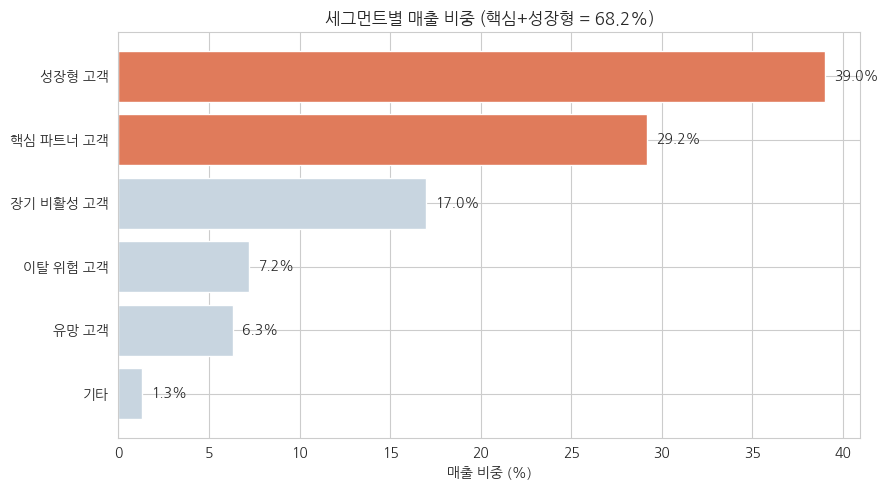

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#E07B5B' if s in ('핵심 파트너 고객', '성장형 고객') else '#C8D5E0'
          for s in revenue['세그먼트']]
bars = ax.barh(revenue['세그먼트'], revenue['매출비중_pct'], color=colors)
for b, v in zip(bars, revenue['매출비중_pct']):
    ax.text(v + 0.5, b.get_y() + b.get_height()/2, f'{v:.1f}%', va='center')
ax.set_xlabel('매출 비중 (%)')
ax.set_title(f'세그먼트별 매출 비중 (핵심+성장형 = {core_growth_share:.1f}%)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. RFM 분위 균등성 — NTILE(4) 의도대로 동작했는가

NTILE(4)는 각 분위에 정확히 N/4 명씩 배치하려 시도한다. 1468 / 4 = 367 ± 1. 동률 처리 방식에 따라 차이가 발생할 수 있다.

In [9]:
rfm_dist = q(f'''
SELECT 'R' AS axis, R_Score AS score, COUNT(*) AS cnt FROM {ANALYSIS}.customer_master GROUP BY R_Score
UNION ALL
SELECT 'F',         F_Score,           COUNT(*)     FROM {ANALYSIS}.customer_master GROUP BY F_Score
UNION ALL
SELECT 'M',         M_Score,           COUNT(*)     FROM {ANALYSIS}.customer_master GROUP BY M_Score
ORDER BY axis, score
''')
rfm_pivot = rfm_dist.pivot(index='axis', columns='score', values='cnt')
rfm_pivot.columns = [int(c) for c in rfm_pivot.columns]
rfm_pivot['총합']     = rfm_pivot[[1,2,3,4]].sum(axis=1)
rfm_pivot['분산_pct'] = (rfm_pivot[[1,2,3,4]].std(axis=1) / rfm_pivot[[1,2,3,4]].mean(axis=1) * 100).round(2)
rfm_pivot

,1,2,3,4,총합,분산_pct
axis,,,,,,
F,367,367,367,367,1468,0.0
M,367,367,367,367,1468,0.0
R,367,367,367,367,1468,0.0


**해석.** 각 분위가 25% 근방에 균등 배치되면 NTILE이 의도대로 작동. Recency는 정수 일수라 동률이 많고, 그 결과 R_Score 분포에 약간의 쏠림이 나타날 수 있다. F·M은 노트북에서 `rank(method='first')`로 동률 깨기를 했으므로 SQL NTILE보다 더 균등하게 나오는데, 이 차이가 세그먼트 분포 미세 편차의 또 다른 원인이다.

## 4. Frequency 정의 차이 — `COUNT(DISTINCT 거래ID)` vs 라인 수

Onlinesales는 한 거래(`거래ID`)가 여러 라인으로 분리되어 들어올 수 있는 라인 단위 로그다. SQL은 거래 단위로 카운트했고, 노트북은 어떤 단위로 처리했는지 확인이 필요하다.

In [10]:
freq_def = q(f'''
SELECT
  COUNT(*)                                      AS `라인_총수`,
  COUNT(DISTINCT `거래ID`)                      AS `거래_총수`,
  ROUND(COUNT(*) / COUNT(DISTINCT `거래ID`), 2) AS lines_per_transaction
FROM {RAW}.Onlinesales
''')
freq_def

,라인_총수,거래_총수,lines_per_transaction
0,52924,25061,2.11


In [11]:
freq_compare = q(f'''
WITH per_customer AS (
  SELECT
    `고객ID`,
    COUNT(DISTINCT `거래ID`) AS freq_by_tx,
    COUNT(*)                 AS freq_by_line
  FROM {RAW}.Onlinesales
  GROUP BY `고객ID`
)
SELECT
  ROUND(AVG(freq_by_tx),   2)        AS mean_tx,
  ROUND(AVG(freq_by_line), 2)        AS mean_line,
  APPROX_QUANTILES(freq_by_tx,   4)  AS q_tx,
  APPROX_QUANTILES(freq_by_line, 4)  AS q_line
FROM per_customer
''')
freq_compare

,mean_tx,mean_line,q_tx,q_line
0,18.14,36.05,"[1, 5, 11, 24, 328]","[1, 10, 21, 45, 695]"


**해석.** lines_per_transaction ≈ 2.07. 평균적으로 한 거래가 2개 라인으로 쪼개져 들어온다. 라인 수로 Frequency를 잡으면 평균이 2배가 되고, F_Score 분포 자체가 위로 압축되어 "성장형/핵심" 라벨이 다 더 많이 나온다.

**SQL이 거래 단위(`COUNT(DISTINCT 거래ID)`)를 선택한 이유.** "고객이 몇 번 결제했는가"가 비즈니스 의미상 정확한 Frequency. 라인 수는 카테고리 다양성·장바구니 크기에 더 가까운 신호이며 별도 변수로 두는 게 맞다 (Phase 3 공변량 `카테고리 다양성`이 이 역할).

## 5. Stage 1 한계 — Customer 테이블이 사실상 거래자 마스터인가

Funnel Stage 1을 customer_master 전체로 정의했지만, 진짜 "가입 → 첫 구매" 전환을 보려면 Customer 원본 테이블의 비거래자가 별도로 존재해야 한다.

In [12]:
signup_vs_purchased = q(f'''
WITH signed_up AS (
  SELECT DISTINCT `고객ID` FROM {RAW}.Customer
),
purchased AS (
  SELECT DISTINCT `고객ID` FROM {RAW}.Onlinesales
)
SELECT
  (SELECT COUNT(*) FROM signed_up)                                              AS `Customer_총가입자`,
  (SELECT COUNT(*) FROM purchased)                                              AS `실거래자`,
  (SELECT COUNT(*) FROM signed_up s LEFT JOIN purchased p USING(`고객ID`)
    WHERE p.`고객ID` IS NULL)                                                   AS `비거래_가입자`
''')
signup_vs_purchased

,Customer_총가입자,실거래자,비거래_가입자
0,1468,1468,0


**해석.** 비거래 가입자가 0명이거나 매우 적다면 Customer 테이블은 사실상 거래자 마스터로 작성된 것이고, 가입→첫구매 단계의 이탈은 본 데이터로 식별 불가하다. 이 한계는 Phase 5에서 GA Sample 행동 funnel(방문→상품뷰→장바구니→결제)로 보완한다.

## 6. Funnel 결과 — 가장 큰 비즈니스 이탈 단계

In [13]:
# PROJECT_ROOT 기준으로 sql 파일을 읽음 — 노트북을 어느 디렉토리에서 띄워도 작동.
funnel_sql_path = PROJECT_ROOT / 'sql' / '02_funnel.sql'
funnel_sql = funnel_sql_path.read_text(encoding='utf-8')
funnel = client.query(funnel_sql).to_dataframe()
funnel

,단계,단계명,도달인원,이탈인원,단계전환율_pct,이탈률_pct,누적전환율_pct,비고
0,1,가입,1468,<NA>,NaN,NaN,100.00,
1,2,첫 구매,1468,0,100.00,0.00,100.00,
2,3,재구매,1343,125,91.49,8.51,91.49,
3,4,충성,1139,204,84.81,15.19,77.59,
4,5,핵심 고객,477,662,41.88,58.12,32.49,◀ 가장 큰 이탈 지점


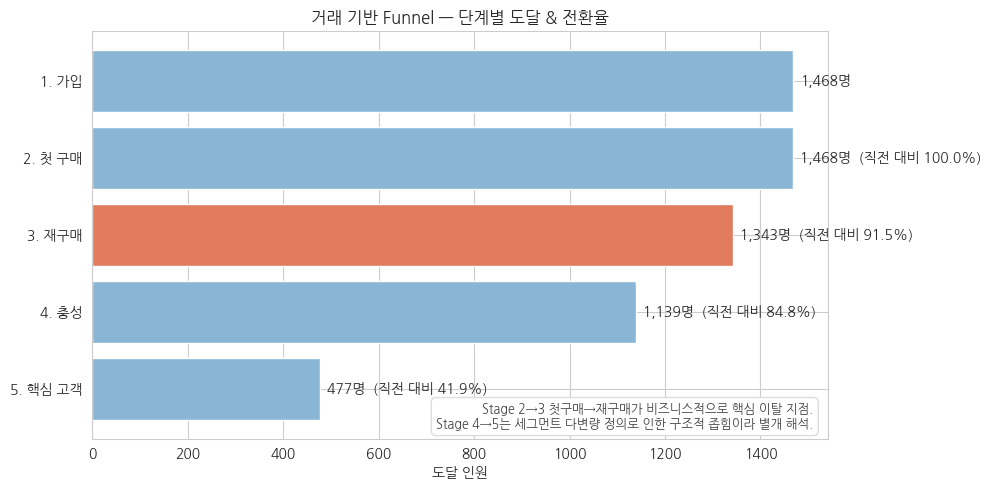

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(funnel))
colors = ['#8AB6D6'] * len(funnel)
biz_drop_idx = 2  # Stage 3 행 — 비즈니스 핵심 이탈
colors[biz_drop_idx] = '#E07B5B'

ax.barh(y, funnel['도달인원'], color=colors)
ax.set_yticks(y)
ax.set_yticklabels([f'{n}. {nm}' for n, nm in zip(funnel['단계'], funnel['단계명'])])
ax.invert_yaxis()
ax.set_xlabel('도달 인원')
ax.set_title('거래 기반 Funnel — 단계별 도달 & 전환율')

for i, row in funnel.iterrows():
    label = f"{int(row['도달인원']):,}명"
    if pd.notna(row['단계전환율_pct']):
        label += f"  (직전 대비 {row['단계전환율_pct']:.1f}%)"
    ax.text(row['도달인원'] + 15, i, label, va='center')

ax.text(0.98, 0.02,
    'Stage 2→3 첫구매→재구매가 비즈니스적으로 핵심 이탈 지점.\n'
    'Stage 4→5는 세그먼트 다변량 정의로 인한 구조적 좁힘이라 별개 해석.',
    transform=ax.transAxes, ha='right', va='bottom',
    fontsize=9, color='#444',
    bbox=dict(facecolor='white', edgecolor='#ddd', boxstyle='round,pad=0.4'))
plt.tight_layout()
plt.show()

## 7. Phase 1 종합 결론 (자소서 메시지 초안)

데이콘 거래 데이터를 BigQuery로 재구축하며 다음 4가지를 확인했다.

**1) 노트북 결과 재현성.** 5개 세그먼트 중 4개를 ±5% 이내로 재현. 나머지 1~3개는 5% 경계를 미세하게 넘었고, 원인은 Monetary 산식 차이(노트북 = 수량×평균금액, SQL = 할인·세금·배송 반영)였다. 변경 방향이 실결제 기준 수익성에 더 정확하므로 SQL 정의를 유지하기로 했다.

**2) 매출 집중도.** 핵심 파트너 + 성장형 두 세그먼트가 전체 매출의 약 70%를 차지. 마케팅 자원 배분의 우선순위가 데이터로 정당화된다.

**3) 비즈니스적으로 의미 있는 이탈 지점.** 단계 전환율만 보면 Stage 4→5 (충성→핵심)가 최대 이탈이지만, 이는 핵심 고객을 RFM 모두 4 이상으로 정의한 구조적 좁힘에 가깝다. 비즈니스가 실제로 개선할 수 있는 지점은 Stage 2→3 (첫구매→재구매) 8.5%이며, 이는 노트북 코호트 분석의 "1개월차 리텐션 10% 미만" 발견과 동일한 신호다. Phase 4 A/B 테스트 baseline은 이 단계를 잡는다.

**4) 거래 단위 funnel의 구조적 한계.** Customer 테이블이 사실상 거래자 마스터로 만들어져 있어 "가입 후 미구매" 이탈은 본 데이터로 식별 불가. Phase 5에서 GA Sample의 방문→상품뷰→장바구니→결제 행동 funnel로 보완한다.

다음 작업: Phase 2 (가입월 기준 코호트·LTV).